In [2]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("steel-faults.csv")

In [3]:
df.head()

,X_Minimum,X_Maximum,Y_Minimum,Y_Maximum,Pixels_Areas,X_Perimeter,Y_Perimeter,Sum_of_Luminosity,Minimum_of_Luminosity,Maximum_of_Luminosity,...,Orientation_Index,Luminosity_Index,SigmoidOfAreas,Pastry,Z_Scratch,K_Scatch,Stains,Dirtiness,Bumps,Other_Faults
0,42,50,270900,270944,267,17,44,24220,76,108,...,0.8182,-0.2913,0.5822,1,0,0,0,0,0,0
1,645,651,2538079,2538108,108,10,30,11397,84,123,...,0.7931,-0.1756,0.2984,1,0,0,0,0,0,0
2,829,835,1553913,1553931,71,8,19,7972,99,125,...,0.6667,-0.1228,0.2150,1,0,0,0,0,0,0
3,853,860,369370,369415,176,13,45,18996,99,126,...,0.8444,-0.1568,0.5212,1,0,0,0,0,0,0
4,1289,1306,498078,498335,2409,60,260,246930,37,126,...,0.9338,-0.1992,1.0000,1,0,0,0,0,0,0


In [4]:
df.rename(columns={"K_Scatch": "K_Scratch"}, inplace=True)

Observation: feature name was incorrect 

In [5]:
df.shape

(1941, 34)

Observation: There are total 1941 records and 34 features out of 34, 7 are dependent columns and rest of them 27 are independent column 

In [6]:
df.isnull().sum()

X_Minimum                0
X_Maximum                0
Y_Minimum                0
Y_Maximum                0
Pixels_Areas             0
X_Perimeter              0
Y_Perimeter              0
Sum_of_Luminosity        0
Minimum_of_Luminosity    0
Maximum_of_Luminosity    0
Length_of_Conveyer       0
TypeOfSteel_A300         0
TypeOfSteel_A400         0
Steel_Plate_Thickness    0
Edges_Index              0
Empty_Index              0
Square_Index             0
Outside_X_Index          0
Edges_X_Index            0
Edges_Y_Index            0
Outside_Global_Index     0
LogOfAreas               0
Log_X_Index              0
Log_Y_Index              0
Orientation_Index        0
Luminosity_Index         0
SigmoidOfAreas           0
Pastry                   0
Z_Scratch                0
K_Scratch                0
Stains                   0
Dirtiness                0
Bumps                    0
Other_Faults             0
dtype: int64

Observation: There is no null in this data

In [7]:
df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 1941 entries, 0 to 1940
Data columns (total 34 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   X_Minimum              1941 non-null   int64  
 1   X_Maximum              1941 non-null   int64  
 2   Y_Minimum              1941 non-null   int64  
 3   Y_Maximum              1941 non-null   int64  
 4   Pixels_Areas           1941 non-null   int64  
 5   X_Perimeter            1941 non-null   int64  
 6   Y_Perimeter            1941 non-null   int64  
 7   Sum_of_Luminosity      1941 non-null   int64  
 8   Minimum_of_Luminosity  1941 non-null   int64  
 9   Maximum_of_Luminosity  1941 non-null   int64  
 10  Length_of_Conveyer     1941 non-null   int64  
 11  TypeOfSteel_A300       1941 non-null   int64  
 12  TypeOfSteel_A400       1941 non-null   int64  
 13  Steel_Plate_Thickness  1941 non-null   int64  
 14  Edges_Index            1941 non-null   float64
 15  Empty_Index    

,X_Minimum,X_Maximum,Y_Minimum,Y_Maximum,Pixels_Areas,X_Perimeter,Y_Perimeter,Sum_of_Luminosity,Minimum_of_Luminosity,Maximum_of_Luminosity,...,Orientation_Index,Luminosity_Index,SigmoidOfAreas,Pastry,Z_Scratch,K_Scratch,Stains,Dirtiness,Bumps,Other_Faults
count,1941.000000,1941.000000,1.941000e+03,1.941000e+03,1941.000000,1941.000000,1941.000000,1.941000e+03,1941.000000,1941.000000,...,1941.000000,1941.000000,1941.000000,1941.000000,1941.000000,1941.000000,1941.000000,1941.000000,1941.000000,1941.000000
mean,571.136012,617.964451,1.650685e+06,1.650739e+06,1893.878413,111.855229,82.965997,2.063121e+05,84.548686,130.193715,...,0.083288,-0.131305,0.585420,0.081401,0.097888,0.201443,0.037094,0.028336,0.207110,0.346728
std,520.690671,497.627410,1.774578e+06,1.774590e+06,5168.459560,301.209187,426.482879,5.122936e+05,32.134276,18.690992,...,0.500868,0.148767,0.339452,0.273521,0.297239,0.401181,0.189042,0.165973,0.405339,0.476051
min,0.000000,4.000000,6.712000e+03,6.724000e+03,2.000000,2.000000,1.000000,2.500000e+02,0.000000,37.000000,...,-0.991000,-0.998900,0.119000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,51.000000,192.000000,4.712530e+05,4.712810e+05,84.000000,15.000000,13.000000,9.522000e+03,63.000000,124.000000,...,-0.333300,-0.195000,0.248200,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,435.000000,467.000000,1.204128e+06,1.204136e+06,174.000000,26.000000,25.000000,1.920200e+04,90.000000,127.000000,...,0.095200,-0.133000,0.506300,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,1053.000000,1072.000000,2.183073e+06,2.183084e+06,822.000000,84.000000,83.000000,8.301100e+04,106.000000,140.000000,...,0.511600,-0.066600,0.999800,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
max,1705.000000,1713.000000,1.298766e+07,1.298769e+07,152655.000000,10449.000000,18152.000000,1.159141e+07,203.000000,253.000000,...,0.991700,0.642100,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [8]:
fault_cols = [
    "Pastry", "Z_Scratch", "K_Scratch", "Stains",
    "Dirtiness", "Bumps", "Other_Faults"
]

df["Fault_Type"] = df[fault_cols].idxmax(axis=1)

In [9]:
df.head()

,X_Minimum,X_Maximum,Y_Minimum,Y_Maximum,Pixels_Areas,X_Perimeter,Y_Perimeter,Sum_of_Luminosity,Minimum_of_Luminosity,Maximum_of_Luminosity,...,Luminosity_Index,SigmoidOfAreas,Pastry,Z_Scratch,K_Scratch,Stains,Dirtiness,Bumps,Other_Faults,Fault_Type
0,42,50,270900,270944,267,17,44,24220,76,108,...,-0.2913,0.5822,1,0,0,0,0,0,0,Pastry
1,645,651,2538079,2538108,108,10,30,11397,84,123,...,-0.1756,0.2984,1,0,0,0,0,0,0,Pastry
2,829,835,1553913,1553931,71,8,19,7972,99,125,...,-0.1228,0.2150,1,0,0,0,0,0,0,Pastry
3,853,860,369370,369415,176,13,45,18996,99,126,...,-0.1568,0.5212,1,0,0,0,0,0,0,Pastry
4,1289,1306,498078,498335,2409,60,260,246930,37,126,...,-0.1992,1.0000,1,0,0,0,0,0,0,Pastry


Observation: Created new column to target feature for visualization purpose 

Fault_Type
Other_Faults    673
Bumps           402
K_Scratch       391
Z_Scratch       190
Pastry          158
Stains           72
Dirtiness        55
Name: count, dtype: int64

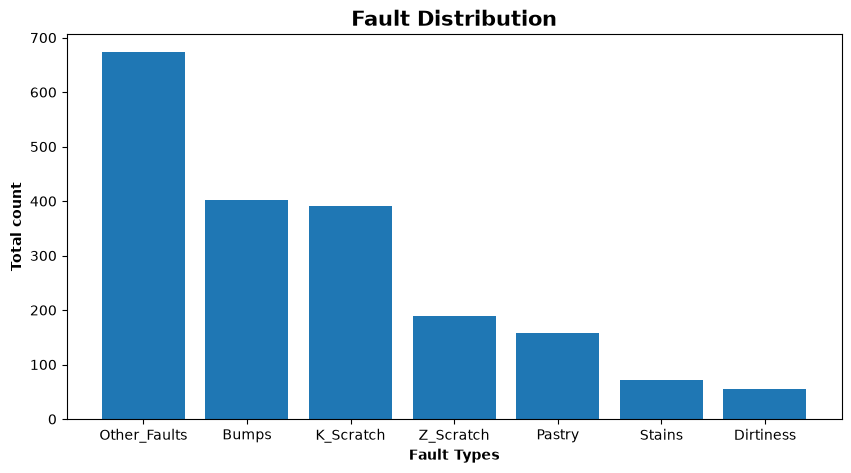

In [10]:
fault_count = df["Fault_Type"].value_counts()
plt.figure(figsize = (10,5))
plt.bar(fault_count.index, fault_count.values)
plt.title("Fault Distribution",fontweight = "bold",fontsize = 15)
plt.xlabel("Fault Types",fontweight = "bold")
plt.ylabel("Total count",fontweight = "bold")
df["Fault_Type"].value_counts()

Observation: From the above plot, Other_Faults has the highest number of occurrences among all the fault types, "Bumps" and "K_Scratch" was distribution closely

<Axes: >

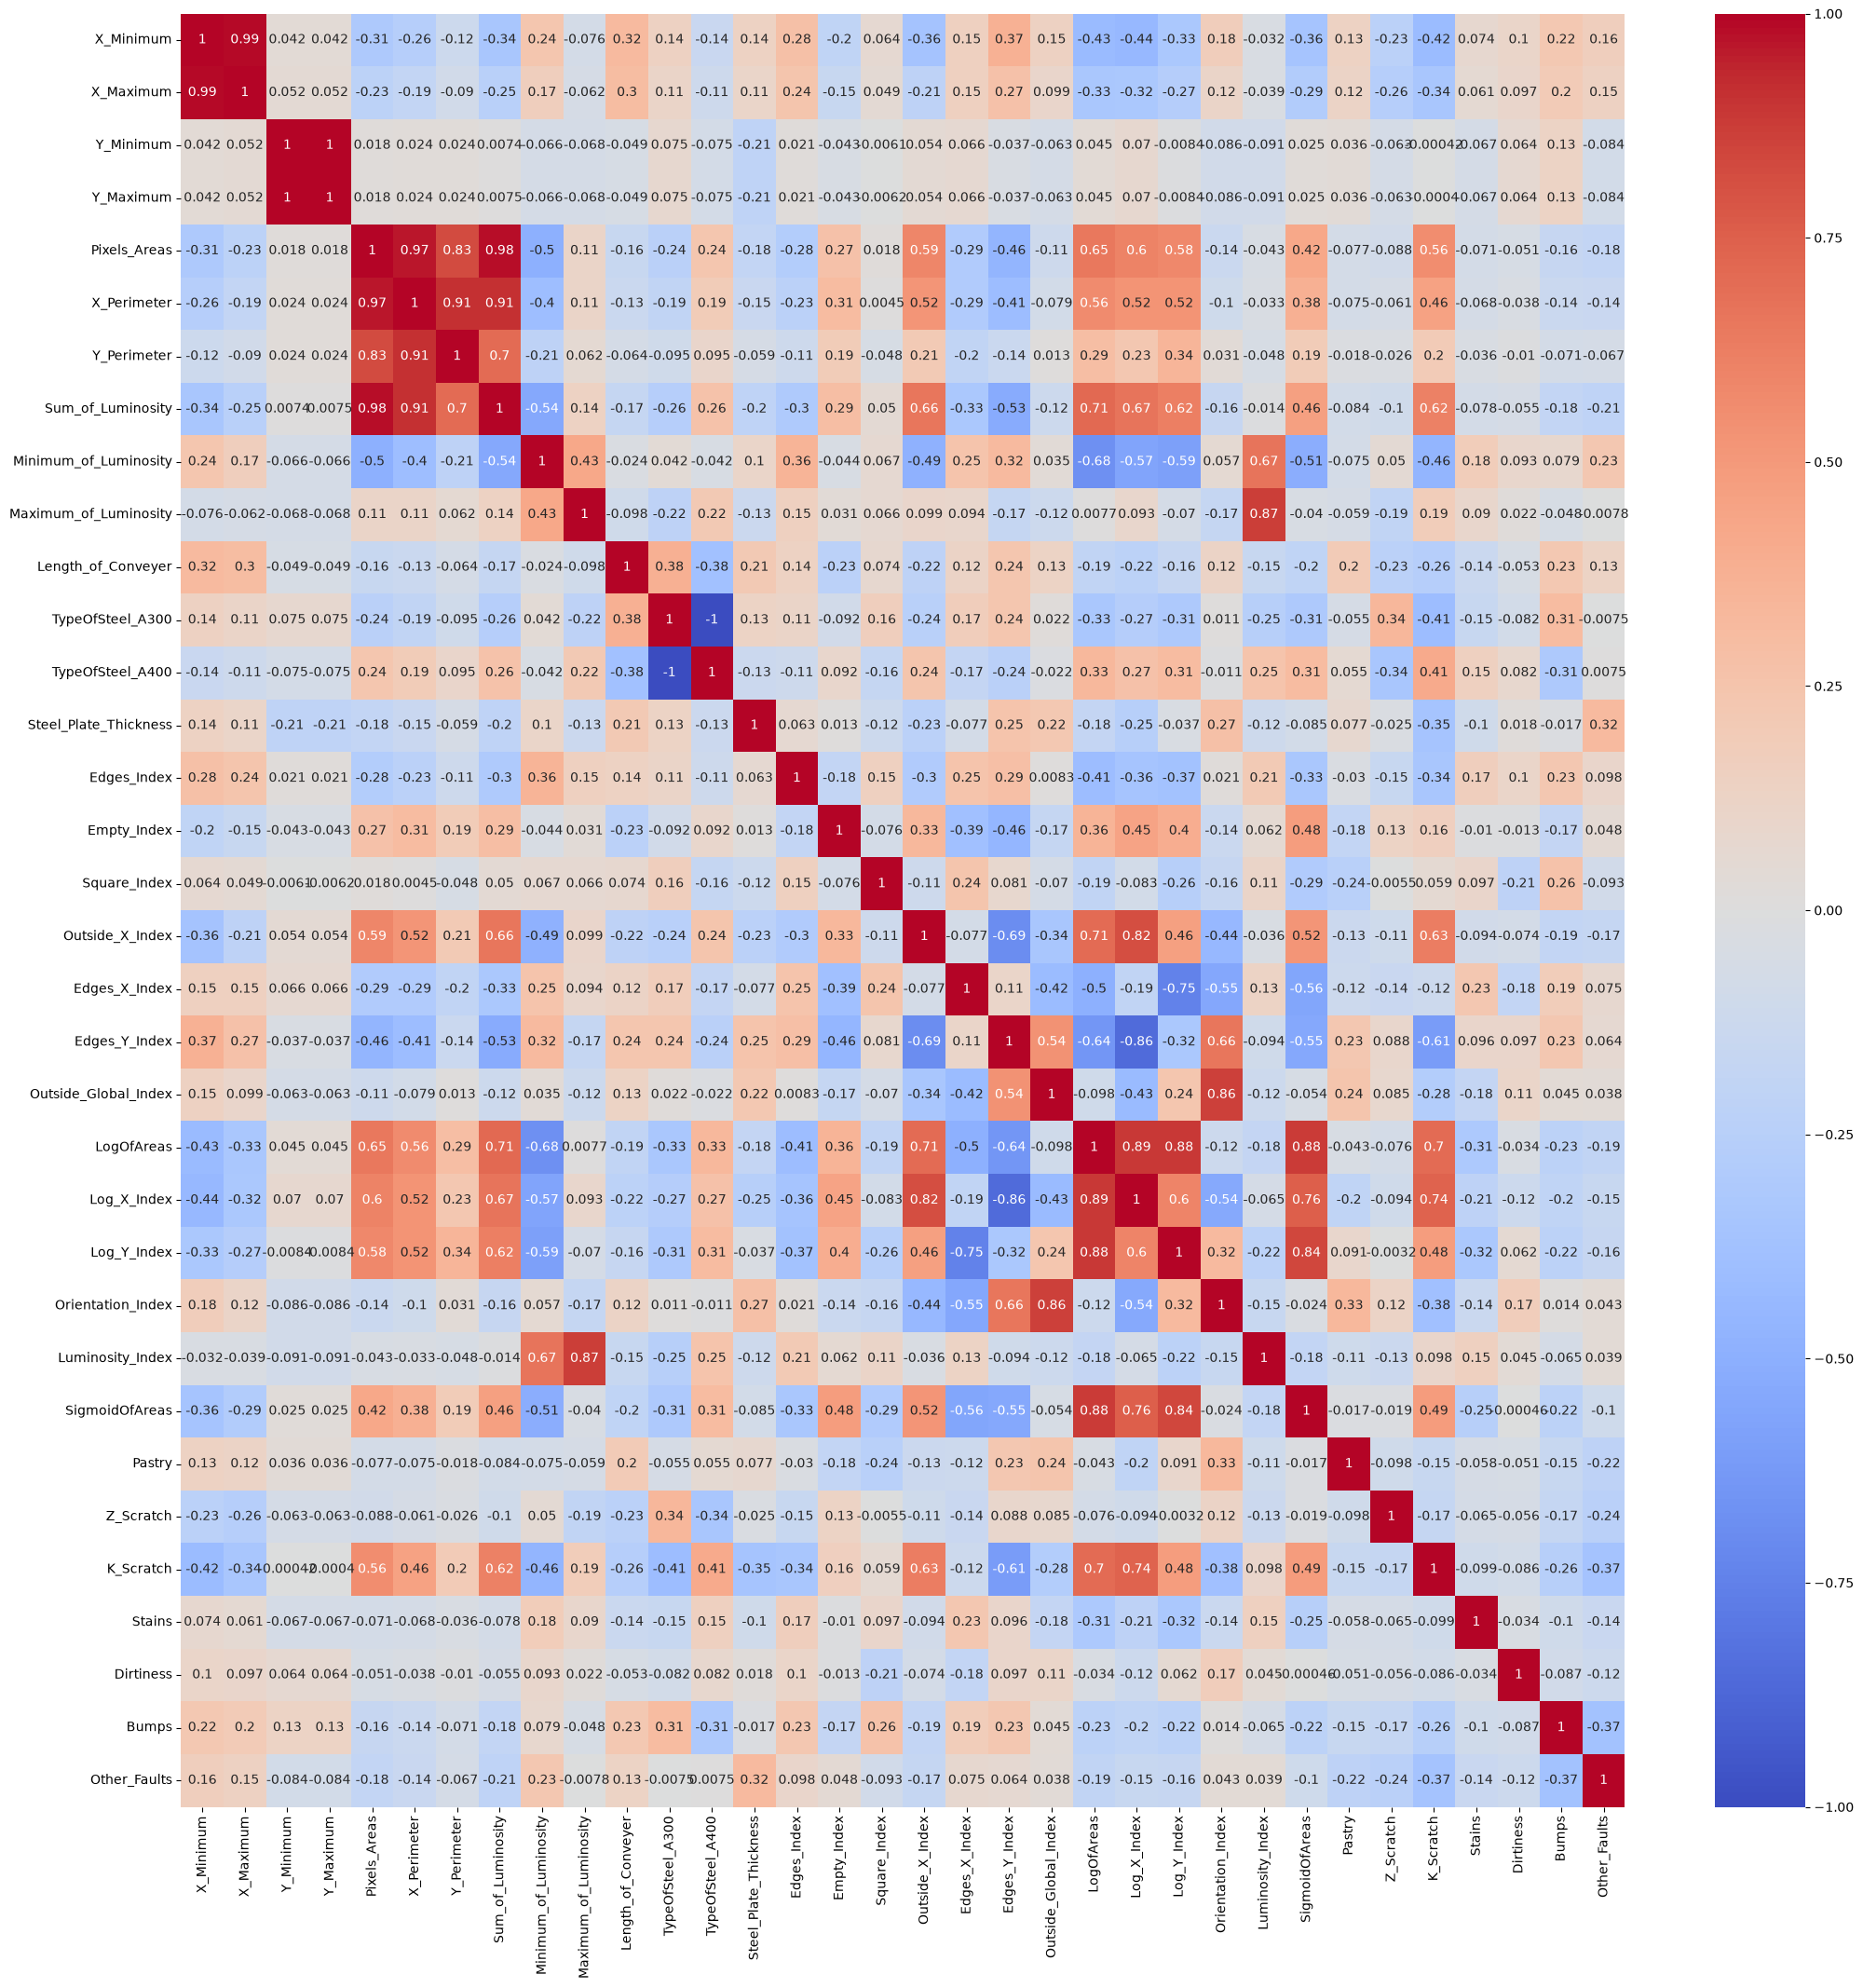

In [11]:
corr = df.select_dtypes(include = "number").corr()
plt.figure(figsize = (25, 25))
sns.heatmap(corr, cmap = "coolwarm", annot = True)

Observation: from above heat map we can see correlation numbers of the target feautures with every independent feature

([0, 1, 2, 3, 4, 5, 6],
 [Text(0, 0, 'Pastry'),
  Text(1, 0, 'Z_Scratch'),
  Text(2, 0, 'K_Scratch'),
  Text(3, 0, 'Stains'),
  Text(4, 0, 'Dirtiness'),
  Text(5, 0, 'Bumps'),
  Text(6, 0, 'Other_Faults')])

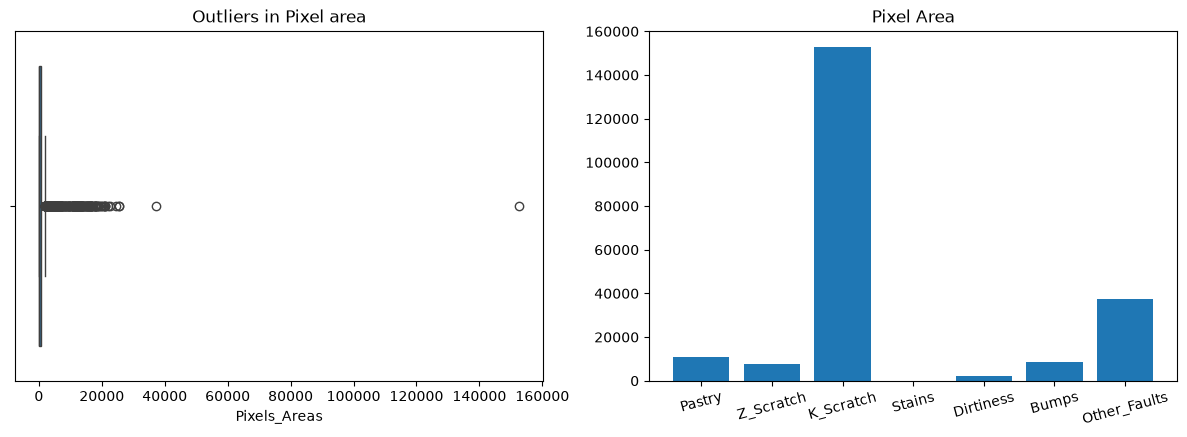

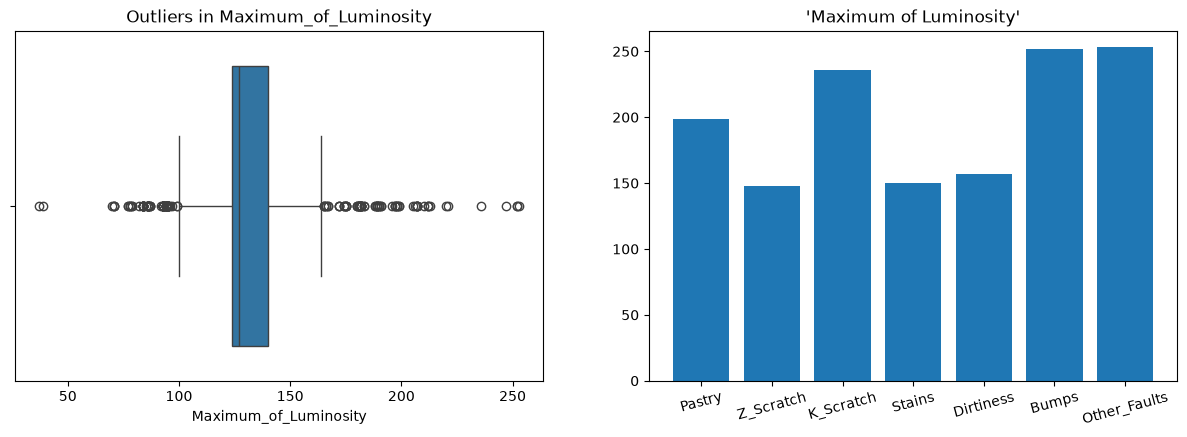

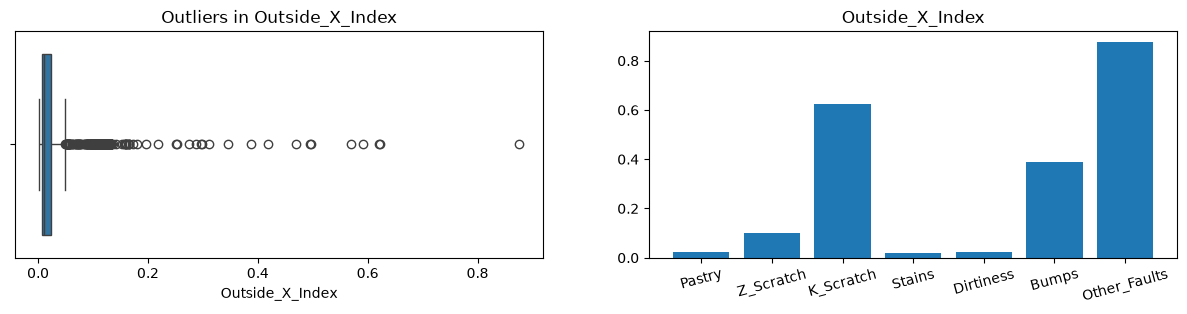

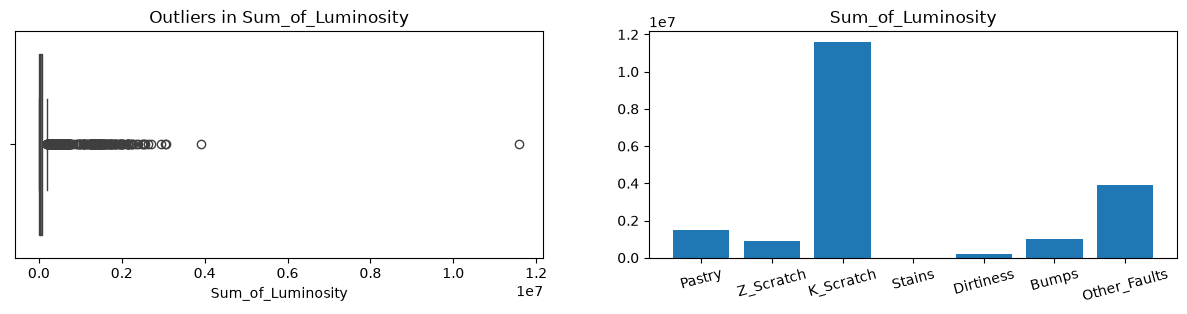

In [12]:
plt.figure(figsize=(15, 10))

plt.subplot(2, 2, 1)
sns.boxplot(x='Pixels_Areas', data=df)
plt.title("Outliers in Pixel area")

plt.subplot(2, 2, 2)
plt.bar(df["Fault_Type"],df['Pixels_Areas'])
plt.title("Pixel Area")
plt.xticks(rotation = 15)


plt.figure(figsize=(15, 10))

plt.subplot(2, 2, 3)
sns.boxplot(x='Maximum_of_Luminosity', data=df)
plt.title("Outliers in Maximum_of_Luminosity")

plt.subplot(2, 2, 4)
plt.bar(df["Fault_Type"],df['Maximum_of_Luminosity'])
plt.title("'Maximum of Luminosity'")
plt.xticks(rotation = 15)

plt.figure(figsize=(15, 10))

plt.subplot(3, 2, 1)
sns.boxplot(x= "Outside_X_Index" , data=df)
plt.title("Outliers in Outside_X_Index")

plt.subplot(3, 2, 2)
plt.bar(df["Fault_Type"],df['Outside_X_Index'])
plt.title("Outside_X_Index")
plt.xticks(rotation = 15)

plt.figure(figsize=(15, 10))

plt.subplot(3, 2, 3)
sns.boxplot(x= "Sum_of_Luminosity" , data=df)
plt.title("Outliers in Sum_of_Luminosity")

plt.subplot(3, 2, 4)
plt.bar(df["Fault_Type"],df['Sum_of_Luminosity'])
plt.title("Sum_of_Luminosity")
plt.xticks(rotation = 15)


observation: I checked all 27 independent columns using box plots. 15 columns showed potential outliers. The 4 box plots above are examples of these outliers.

In [13]:
# feature_cols = [col for col in df.columns if col not in fault_cols]

# for feature in feature_cols:
#     plt.figure(figsize=(8, 5))
#     sns.boxplot(x=feature, data=df)
#     plt.tight_layout()
#     plt.show()

Observation: To check all outliers using box plot

In [14]:
df.drop('Fault_Type', axis = 1, inplace = True)

In [15]:
df.head()

,X_Minimum,X_Maximum,Y_Minimum,Y_Maximum,Pixels_Areas,X_Perimeter,Y_Perimeter,Sum_of_Luminosity,Minimum_of_Luminosity,Maximum_of_Luminosity,...,Orientation_Index,Luminosity_Index,SigmoidOfAreas,Pastry,Z_Scratch,K_Scratch,Stains,Dirtiness,Bumps,Other_Faults
0,42,50,270900,270944,267,17,44,24220,76,108,...,0.8182,-0.2913,0.5822,1,0,0,0,0,0,0
1,645,651,2538079,2538108,108,10,30,11397,84,123,...,0.7931,-0.1756,0.2984,1,0,0,0,0,0,0
2,829,835,1553913,1553931,71,8,19,7972,99,125,...,0.6667,-0.1228,0.2150,1,0,0,0,0,0,0
3,853,860,369370,369415,176,13,45,18996,99,126,...,0.8444,-0.1568,0.5212,1,0,0,0,0,0,0
4,1289,1306,498078,498335,2409,60,260,246930,37,126,...,0.9338,-0.1992,1.0000,1,0,0,0,0,0,0


Observation: "Fault_Type" column has been drop which is not required for the model Previously we created this feature for visualization purpose

In [16]:
df.head()

x = df.iloc[:,:27]
y = df.iloc[:,27:]

Observation: x and y data seperation has been done 

x = Independent Features 

y = Dependent Features

In [17]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size= 0.20, random_state = 8)

Observation: we splitted this data for testing 20%, train 80% and saved this split using random state 

Random Frorest Model

In [18]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=300,class_weight="balanced",random_state=42)
rf.fit(x_train,  y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"class_weight class_weight: {""balanced"", ""balanced_subsample""}, dict or list of dicts, default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one. Formulti-output problems, a list of dicts can be provided in the sameorder as the columns of y.Note that for multioutput (including multilabel) weights should bedefined for each class of every column in its own dict. For example,for four-class multilabel classification weights should be[{0: 1, 1: 1}, {0: 1, 1: 5}, {0: 1, 1: 1}, {0: 1, 1: 1}] instead of[{1:1}, {2:5}, {3:1}, {4:1}].The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``The ""balanced_subsample"" mode is the same as ""balanced"" except thatweights are computed based on the bootstrap sample for every treegrown.For multi-output, the weights of each column of y will be multiplied.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified.",'balanced'
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.

In [19]:
test_pred = rf.predict(x_test)
train_pred = rf.predict(x_train)

In [20]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

print("Test Accuracy:", accuracy_score(y_test, test_pred))

print("Test Precision:", precision_score(y_test, test_pred, average="micro", zero_division=0))

print("Test Recall:", recall_score(y_test, test_pred, average="micro", zero_division=0))

print("Test F1:", f1_score(y_test, test_pred, average="micro", zero_division=0))

Test Accuracy: 0.6529562982005142
Test Precision: 0.8881118881118881
Test Recall: 0.6529562982005142
Test F1: 0.7525925925925926


In [21]:
print("Train Accuracy:", accuracy_score(y_train, train_pred))

print("Train Precision:", precision_score(y_train, train_pred, average="micro", zero_division=0))

print("Train Recall:", recall_score(y_train, train_pred, average="micro", zero_division=0))

print("Train F1:", f1_score(y_train, train_pred, average="micro", zero_division=0))

Train Accuracy: 0.8692010309278351
Train Precision: 0.9712023038156947
Train Recall: 0.8692010309278351
Train F1: 0.9173750425025502


Decision Tree Model

In [22]:
from sklearn.tree import DecisionTreeClassifier
dt = DecisionTreeClassifier()
dt.fit(x_train, y_train) 

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split among considered features for this split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: splitting may inspect more than ``max_features`` features ifneeded to find a valid split.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of sampl

In [23]:
test_pred = dt.predict(x_test)
train_pred = dt.predict(x_train)

In [24]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

print("Test Accuracy:", accuracy_score(y_test, test_pred))

print("Test Precision:", precision_score(y_test, test_pred, average="micro", zero_division=0))

print("Test Recall:", recall_score(y_test, test_pred, average="micro", zero_division=0))

print("Test F1:", f1_score(y_test, test_pred, average="micro", zero_division=0))

Test Accuracy: 0.7275064267352185
Test Precision: 0.7275064267352185
Test Recall: 0.7275064267352185
Test F1: 0.7275064267352185


In [25]:
print("Train Accuracy:", accuracy_score(y_train, train_pred))

print("Train Precision:", precision_score(y_train, train_pred, average="micro", zero_division=0))

print("Train Recall:", recall_score(y_train, train_pred, average="micro", zero_division=0))

print("Train F1:", f1_score(y_train, train_pred, average="micro", zero_division=0))

Train Accuracy: 1.0
Train Precision: 1.0
Train Recall: 1.0
Train F1: 1.0


In [26]:
# %pip install xgboost

XGBoost Model

In [27]:
import xgboost as xgb
xgb = xgb.XGBClassifier()
xgb.fit(x_train, y_train)


,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,None
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",None
,feature_types feature_types: typing.Sequence[str] | None.. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [28]:
test_pred_xgb = xgb.predict(x_test)
train_pred_xgb = xgb.predict(x_train)

In [29]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

print("Test Accuracy:", accuracy_score(y_test, test_pred_xgb))

print("Test Precision:", precision_score(y_test, test_pred_xgb, average="micro", zero_division=0))

print("Test Recall:", recall_score(y_test, test_pred_xgb, average="micro", zero_division=0))

print("Test F1:", f1_score(y_test, test_pred_xgb, average="micro", zero_division=0))

Test Accuracy: 0.7532133676092545
Test Precision: 0.8595505617977528
Test Recall: 0.7866323907455013
Test F1: 0.8214765100671141


In [30]:
print("Train Accuracy:", accuracy_score(y_train, train_pred_xgb))

print("Train Precision:", precision_score(y_train, train_pred_xgb, average="micro", zero_division=0))

print("Train Recall:", recall_score(y_train, train_pred_xgb, average="micro", zero_division=0))

print("Train F1:", f1_score(y_train, train_pred_xgb, average="micro", zero_division=0))

Train Accuracy: 1.0
Train Precision: 1.0
Train Recall: 1.0
Train F1: 1.0


Observation: After comparing accuracy scores of these 3 models we decided to go with XgBoost model, Because it give better score from rest of 2 models 

In [31]:
importance = pd.Series(
    xgb.feature_importances_,
    index=x.columns
).sort_values(ascending=False)

print(importance)

Log_X_Index              0.291221
TypeOfSteel_A300         0.143703
Pixels_Areas             0.094020
Orientation_Index        0.047361
Steel_Plate_Thickness    0.045342
Length_of_Conveyer       0.037429
Y_Perimeter              0.030335
X_Minimum                0.028192
Minimum_of_Luminosity    0.025967
Sum_of_Luminosity        0.024324
Square_Index             0.024162
Edges_Y_Index            0.023228
Luminosity_Index         0.019586
Outside_X_Index          0.019476
Outside_Global_Index     0.018447
Maximum_of_Luminosity    0.017498
Y_Minimum                0.016918
X_Maximum                0.016626
Edges_Index              0.014707
Log_Y_Index              0.013193
Empty_Index              0.013032
X_Perimeter              0.012861
Edges_X_Index            0.011651
SigmoidOfAreas           0.010721
Y_Maximum                0.000000
TypeOfSteel_A400         0.000000
LogOfAreas               0.000000
dtype: float32


Observation: From above series these features "Y_Maximum, TypeOfSteel_A400, LogOfAreas" has no relation with target features

In [32]:
df.drop(['Y_Maximum', 'TypeOfSteel_A400', 'LogOfAreas'],inplace = True, axis = 1)

Observation: After Dropping these features the scores  may be have improve

In [33]:
import xgboost as xgb
from sklearn.multioutput import MultiOutputClassifier
from sklearn.metrics import accuracy_score

xgb_model = xgb.XGBClassifier(
    n_estimators=200,
    max_depth=3,
    learning_rate=0.05,
    min_child_weight=3,
    subsample=0.8,
    colsample_bytree=0.8,
    gamma=0.1,
    reg_alpha=0.01,
    reg_lambda=2,
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42,
    n_jobs=-1
)

multi_xgb = MultiOutputClassifier(xgb_model)


multi_xgb.fit(x_train, y_train)


train_pred_xgb = multi_xgb.predict(x_train)
test_pred_xgb = multi_xgb.predict(x_test)


train_accuracy = accuracy_score(y_train, train_pred_xgb)
test_accuracy = accuracy_score(y_test, test_pred_xgb)

print("Train Accuracy:", train_accuracy)
print("Test Accuracy:", test_accuracy)


Train Accuracy: 0.7899484536082474
Test Accuracy: 0.7429305912596401


In [34]:
import xgboost as xgb
from sklearn.multioutput import MultiOutputClassifier
from sklearn.metrics import accuracy_score

# XGBoost model
xgb_model = xgb.XGBClassifier(
       max_depth=4,            
       learning_rate=0.05,     
       n_estimators=150,
       subsample=0.8,          
       colsample_bytree=0.8,   
       reg_alpha=1.0,         
       reg_lambda=1.0,         
       random_state=8
)

# Multi-label XGBoost
multi_xgb = MultiOutputClassifier(xgb_model)

# Train
multi_xgb.fit(x_train, y_train)

# Predictions
train_pred_xgb = multi_xgb.predict(x_train)
test_pred_xgb = multi_xgb.predict(x_test)

# Accuracy
train_accuracy = accuracy_score(y_train, train_pred_xgb)
test_accuracy = accuracy_score(y_test, test_pred_xgb)



print("Train Accuracy:", train_accuracy)
print("Test Accuracy:", test_accuracy)




Train Accuracy: 0.8537371134020618
Test Accuracy: 0.7429305912596401


Final Model(XGBoost)

In [35]:
import xgboost as xgb
from sklearn.multioutput import ClassifierChain
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score


xgb_model = xgb.XGBClassifier(
    n_estimators=140,
    max_depth=3,
    learning_rate=0.045,
    min_child_weight=2,
    subsample=0.8,
    colsample_bytree=0.9,
    gamma=0.15,
    reg_alpha=0,
    reg_lambda=2,
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42,
    n_jobs=-1
)


model = ClassifierChain(
    xgb_model,
    order=None,
    cv=None
)


model.fit(x_train, y_train)




,estimator estimator: estimatorThe base estimator from which the classifier chain is built.,"XGBClassifier...ree=None, ...)"
,"order order: array-like of shape (n_outputs,) or 'random', default=NoneIf `None`, the order will be determined by the order of columns inthe label matrix Y.:: order = [0, 1, 2, ..., Y.shape[1] - 1]The order of the chain can be explicitly set by providing a list ofintegers. For example, for a chain of length 5.:: order = [1, 3, 2, 4, 0]means that the first model in the chain will make predictions forcolumn 1 in the Y matrix, the second model will make predictionsfor column 3, etc.If order is `random` a random ordering will be used.",None
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines whether to use cross validated predictions or truelabels for the results of previous estimators in the chain.Possible inputs for cv are:- None, to use true labels when fitting,- integer, to specify the number of folds in a (Stratified)KFold,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.",None
,"chain_method chain_method: {'predict', 'predict_proba', 'predict_log_proba', 'decision_function'} or list of such str's, default='predict'Prediction method to be used by estimators in the chain forthe 'prediction' features of previous estimators in the chain.- if `str`, name of the method;- if a list of `str`, provides the method names in order of preference. The method used corresponds to the first method in the list that is implemented by `base_estimator`... versionadded:: 1.5",'predict'
,"random_state random_state: int, RandomState instance or None, optional (default=None)If ``order='random'``, determines random number generation for thechain order.In addition, it controls the random seed given at each `base_estimator`at each chaining iteration. Thus, it is only used when `base_estimator`exposes a `random_state`.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",None
,"verbose verbose: bool, default=FalseIf True, chain progress is output as each model is completed... versionadded:: 1.2",False
Name,Type,Value
chain_method_ chain_method_: strPrediction method used by estimators in the chain for the predictionfeatures.,str,'predict'
classes_ classes_: listA list of arrays of length ``len(estimators_)`` containing theclass labels for each estimator in the chain.,list,"[array([0, 1]), array([0, 1]), array([0, 1]), array([0, 1]), ...]"
estimators_ estimators_: listA list of clones of base_estimator.,list,"[XGBClassifier...ree=None, ...), XGBClassifier...ree=None, ...), XGBClassifier...ree=None, ...), XGBClassifier...ree=None, ...), ...]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](27,)","['X_Minimum','X_Maximum','Y_Minimum',...,'Orientation_Index', 'Luminosity_Index','SigmoidOfAreas']"


In [36]:
train_pred = model.predict(x_train)
test_pred = model.predict(x_test)

train_accuracy = accuracy_score(y_train, train_pred)
test_accuracy = accuracy_score(y_test, test_pred)

print("Train Accuracy:", round(train_accuracy * 100, 2), "%")
print("Test Accuracy :", round(test_accuracy * 100, 2), "%")

Train Accuracy: 85.37 %
Test Accuracy : 82.01 %


In [37]:
from sklearn.metrics import roc_auc_score
train_roc = roc_auc_score(y_train, train_pred)
test_roc = roc_auc_score(y_test, test_pred)

print("Train roc_auc_score:", round(train_roc * 100, 2), "%")
print("Test roc_auc_score :", round(test_roc * 100, 2), "%")

Train roc_auc_score: 91.05 %
Test roc_auc_score : 88.6 %


In [38]:
from sklearn.metrics import classification_report
print("Classification Report - Test Data")
print(classification_report(
    y_test,
    test_pred,
    target_names=y.columns,
    zero_division=0
))

Classification Report - Test Data
              precision    recall  f1-score   support

      Pastry       0.74      0.54      0.62        26
   Z_Scratch       0.97      0.88      0.93        43
   K_Scratch       0.97      0.93      0.95        74
      Stains       0.93      1.00      0.96        13
   Dirtiness       0.87      0.72      0.79        18
       Bumps       0.81      0.74      0.77        84
Other_Faults       0.71      0.84      0.77       131

   micro avg       0.82      0.82      0.82       389
   macro avg       0.86      0.81      0.83       389
weighted avg       0.83      0.82      0.82       389
 samples avg       0.82      0.82      0.82       389



In [39]:
from sklearn.metrics import classification_report

print("Classification Report - Train Data")
print(classification_report(
    y_train,
    train_pred,
    target_names=y.columns,
    zero_division=0
))

Classification Report - Train Data
              precision    recall  f1-score   support

      Pastry       0.90      0.74      0.81       132
   Z_Scratch       0.99      0.94      0.97       147
   K_Scratch       0.99      0.98      0.99       317
      Stains       1.00      0.93      0.96        59
   Dirtiness       1.00      0.81      0.90        37
       Bumps       0.80      0.67      0.73       318
Other_Faults       0.75      0.89      0.81       542

   micro avg       0.85      0.85      0.85      1552
   macro avg       0.92      0.85      0.88      1552
weighted avg       0.86      0.85      0.85      1552
 samples avg       0.85      0.85      0.85      1552



In [40]:
import pickle

model_data = {
    "model": model,
    "feature_names": x.columns.tolist(),
    "fault_names": y.columns.tolist()
}

with open("model.pkl", "wb") as file:
    pickle.dump(model_data, file)

print("Model, feature names and fault names saved successfully!")

Model, feature names and fault names saved successfully!
